In [ ]:
'''
EDA - narrative embeddings exploration

Single notebook that loads the dedup'd corpus, reads the cached embedding
matrix produced by eda/build_narrative_embeddings.py, and exercises every
narrative-embeddings utility end-to-end.

to do:
* hyper paramter tuning over keybert options
    * cacche the keybert embeddings
    * advanced options like steering etc
    
Notes
* keybert
    about what you would expect, lot of waymo and historical data. nothing really too unusual there. more what is in the data overall

'''


"\nEDA - narrative embeddings exploration\n\nSingle notebook that loads the dedup'd corpus, reads the cached embedding\nmatrix produced by eda/build_narrative_embeddings.py, and exercises every\nnarrative-embeddings utility end-to-end.\n"

In [2]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import eda_utils_sgo
import eda_utils_dedupe
import eda_utils_embed
import eda_utils_keybert
import eda_utils_bertopic
import eda_utils_neighbors
import eda_utils_emb_cluster

pd.set_option('display.max_rows', 200)
pd.set_option('display.max_columns', 300)
pd.set_option('display.max_colwidth', 200)


In [3]:
%load_ext autoreload
%autoreload 2


## 1. Load + dedupe


In [4]:
from pathlib import Path
repo_root = Path.cwd().parents[1]  # eda/ADS_to_2026_03_16 -> repo root
data_dir = repo_root / 'data' / 'nhtsa'
paths = sorted(data_dir.glob('SGO-2021-01_Incident_Reports_ADS*.csv'))
print('CSVs:', [p.name for p in paths])


CSVs: ['SGO-2021-01_Incident_Reports_ADS_2025_06_16_to_2026_03_16.csv', 'SGO-2021-01_Incident_Reports_ADS_to_2025_06_16.csv']


In [5]:
ads_df = eda_utils_sgo.load_and_concat_csvs([str(p) for p in paths])
ads_df.shape


Only in SGO-2021-01_Incident_Reports_ADS_2025_06_16_to_2026_03_16.csv:
  Any Air Bags Deployed?
  Automation Feature Version
  Automation Feature Version CBI
  Engagement Status
  Make - Unknown
  Roadway-Degraded Surface
  Roadway-Missing/Degraded Marking
  Roadway-No Unusual Conditions
  Roadway-Other-See Narrative
  Roadway-Traffic Incident
  Roadway-Unknown
  Roadway-Wet Surface Condition
  Roadway-Work Zone
  Source - Internal Process Review
  Source - NHTSA VOQ
  Source - Other - See Narrative
  Source - Other Entity
  Source - State or Other Agency
  VIN Decoded
  Was Any Vehicle Towed?
  Weather - Dust Storm
  Weather - Fog/Smoke/Haze
  Weather - Partly Cloudy
  Weather - Severe Hurricane
  Weather - Structure-Indoor
  Weather - Unk - See Narrative
  Were All Passengers Belted?
Only in SGO-2021-01_Incident_Reports_ADS_to_2025_06_16.csv:
  ADAS/ADS Hardware Version
  ADAS/ADS Hardware Version - Unk
  ADAS/ADS Hardware Version CBI
  ADAS/ADS Software Version
  ADAS/ADS Software V

(3120, 164)

In [6]:
dedup_df = eda_utils_dedupe.dedupe_same_incident(ads_df, verbose=True)
narratives = dedup_df['Narrative - Same Incident ID']
n_nonempty = narratives.dropna().astype(str).str.strip().ne('').sum()
print(f"dedup'd rows: {len(dedup_df)}, non-empty narratives: {n_nonempty}")


dedupe_same_incident: 3120 -> 2344 rows (776 duplicates collapsed)
dedup'd rows: 2344, non-empty narratives: 2342


## 2. Load the embedding cache

If this is your first run or you just refreshed the monthly data, run the
build script from the repo root **before** executing this cell:

```bash
python eda/build_narrative_embeddings.py
```

This notebook reads the cache; it does not build it. If the cache is missing
or out of sync with the dedup'd corpus, `embed_texts` will fall back to the
HF Inference Providers API and embed the gap rows. Monitor the elapsed time
on the cell below - cache-only runs are near-instant.


In [7]:
import re

MODEL_ID = 'BAAI/bge-base-en-v1.5'
CACHE_DIR = repo_root / 'data' / 'embeddings'

# Match the script's derived dataset_id - latest YYYY_MM_DD across CSV filenames.
dates = []
for p in paths:
    dates.extend(re.findall(r'(\d{4}_\d{2}_\d{2})', p.name))
DATASET_ID = f'narratives_dedup_to_{max(dates)}'
print('dataset_id:', DATASET_ID)


dataset_id: narratives_dedup_to_2026_03_16


In [8]:
import time
t0 = time.perf_counter()
emb, doc_index = eda_utils_embed.embed_texts(
    narratives,
    model_id=MODEL_ID,
    cache_dir=str(CACHE_DIR),
    dataset_id=DATASET_ID,
)
print(f'embedding matrix: {emb.shape} dtype={emb.dtype}')
print(f'elapsed: {time.perf_counter() - t0:.2f}s')


embedding matrix: (2342, 768) dtype=float32
elapsed: 655.70s


In [9]:
# Align text Series with the embedding matrix.
texts_used = narratives.loc[doc_index]
texts_used.head(3)


0    Other than an update to the highest severity injury alleged field to reflect a minor injury (which is also reflected in the narrative below), the content of this report is unchanged from the initi...
1    An unoccupied Zoox autonomous vehicle was operating at a reduced speed in lane #5 on westbound [XXX] towards Las Vegas Boulevard in Las Vegas, with a sedan (Vehicle 2) directly behind. The Zoox ve...
2    A Zoox vehicle (Vehicle 1) in autonomous mode was traveling southwest on [XXX] towards [XXX] in Santa Monica when it was struck on the passenger side by an SUV (Vehicle 2), traveling southeast on ...
Name: Narrative - Same Incident ID, dtype: str

## 3. KeyBERT keyphrases


In [10]:
corpus_top = eda_utils_keybert.keybert_corpus(
    texts_used, emb,
    model_id=MODEL_ID, top_k=30,
    keyphrase_ngram_range=(1, 3),
    use_mmr=True, diversity=0.5,
)
corpus_top


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

c:\Users\james\claude_code_repos\my-uv-envs\avird-2026-eda\.venv\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\james\.cache\huggingface\hub\models--BAAI--bge-base-en-v1.5. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

,phrase,score
0,vehicle waymo av,751.7005
1,ads engaged autonomous,709.6526
2,impact waymo,539.7319
3,mode,508.8151
4,autonomous vehicle,493.4782
5,california,491.4576
6,pt waymo autonomous,450.5004
7,francisco california collision,439.9202
8,sustained damage waymo,427.7325
9,damage waymo reporting,423.1087


In [11]:
# Per-doc keyphrases for a random sample of 5 incidents.
sample_ix = texts_used.index.to_series().sample(5, random_state=0).tolist()
sample_texts = texts_used.loc[sample_ix]
positions = [doc_index.get_loc(i) for i in sample_ix]
sample_emb = emb[positions]

per_doc = eda_utils_keybert.keybert_per_doc(
    sample_texts, sample_emb,
    model_id=MODEL_ID, top_k=8,
    keyphrase_ngram_range=(1, 3),
)
for k, ix in enumerate(sample_ix):
    print(f'--- incident_index={ix} ---')
    print('text:', str(sample_texts.iloc[k])[:240], '...')
    print('keyphrases:', per_doc['keyphrases'].iloc[k])
    print()


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

--- incident_index=1412 ---
text: On January [XXX], 2026 at 4:41 PM PT a Waymo Autonomous Vehicle ("Waymo AV") operating in Los Angeles, California was in a collision involving a passenger car on [XXX] near [XXX].
The Waymo AV was traveling southeastbound on [XXX] in the r ...
keyphrases: [('vehicle waymo av', 0.7083), ('angeles california collision', 0.7068), ('injury waymo', 0.6602), ('stopped passenger', 0.656), ('vehicles sustained damage', 0.645), ('ads engaged autonomous', 0.5825), ('cars rotated counterclockwise', 0.5644), ('lane', 0.5119)]

--- incident_index=1970 ---
text: On November [XXX], 2024 at 1:54 PM PT a Waymo Autonomous Vehicle ("Waymo AV") operating in San Francisco, California was in a collision involving a passenger car on [XXX] at [XXX]. 
The Waymo AV was traveling west on [XXX] when it came to  ...
keyphrases: [('vehicle waymo av', 0.7337), ('francisco california collision', 0.6711), ('vehicles sustained damage', 0.6498), ('lane change', 0.6073), ('ads engaged au

## 4. BERTopic - HDBSCAN clustering


In [ ]:
'''
Looking for topics that are representative documents
then the key words can suppor thtis
'''

In [12]:
hdb_model, hdb_topics_df, hdb_doc_topic, hdb_doc_index = (
    eda_utils_bertopic.bertopic_fit(
        texts_used, emb,
        clustering='hdbscan',
        min_topic_size=10,
        random_state=0,
    )
)
print('topic count (incl. -1 outliers):', len(hdb_topics_df))
hdb_topics_df.head(20)


topic count (incl. -1 outliers): 43


,topic_id,size,top_words,top_weights
0,-1,161,"the, and, to, of, in, was, av, xxx, on, cruise","[0.022240602455266198, 0.018171120499517458, 0.017444556686350202, 0.016037673247750264, 0.015364086537739609, 0.015224313745888757, 0.01509098684662445, 0.014838729776871127, 0.014708616559032871..."
1,0,246,"car, passenger, waymo, xxx, av, the, at, of, was, on","[0.034489968014478435, 0.032647087709286496, 0.026041448963839343, 0.020699636649067578, 0.02030469817152133, 0.019969190456400422, 0.01957735387322482, 0.018933511752849488, 0.018347541908544512,..."
2,1,184,"waymo, av, the, arizona, at, phoenix, of, xxx, in, was","[0.026752380082836296, 0.02071535540736825, 0.020543048953347087, 0.020502444202979146, 0.019788362789943982, 0.019759109574809114, 0.019642709194788225, 0.019454185302135864, 0.01865802564877451,..."
3,2,162,"suv, waymo, an, av, the, xxx, of, at, was, on","[0.04178226816326106, 0.026642259171296867, 0.021921004290069598, 0.021386791412823902, 0.020784561099657713, 0.020222177725883604, 0.019439816126861353, 0.018574921169410827, 0.018517298815255857..."
4,3,126,"suv, waymo, av, the, an, xxx, of, at, in, was","[0.036379425914945765, 0.026517420044838775, 0.020656830213711373, 0.02056737029331918, 0.01998952186720224, 0.019858234689937134, 0.019734174390753766, 0.019362166766229646, 0.01795865350612179, ..."
5,4,107,"car, passenger, waymo, xxx, the, av, of, angeles, los, was","[0.03699140192448517, 0.03254449586898368, 0.025594822699578957, 0.021385538529418994, 0.020643624450822975, 0.02026496750001286, 0.0192220103404395, 0.018894892583440463, 0.018894892583440463, 0...."
6,5,96,"zoox, vehicle, were, police, and, called, not, autonomy, to, operator","[0.11791874653801077, 0.05922226171770435, 0.03674310499657006, 0.03157123210339989, 0.0308612319583545, 0.029407309265321094, 0.02601301576245295, 0.02547852355627748, 0.025314625207728675, 0.025..."
7,6,92,"heavy, truck, waymo, av, the, xxx, was, of, on, to","[0.07040893095480508, 0.05447782931556352, 0.026390020398117966, 0.021961067420476408, 0.021237830109623077, 0.020322281058823253, 0.018958350600830468, 0.018762246221932732, 0.017615155528700393,..."
8,7,79,"waymo, test, the, xxx, in, av, transdev, was, at, driver","[0.02171358213659167, 0.01938655063120582, 0.019030779706195804, 0.018668424475781382, 0.018646826105200118, 0.018578405882875834, 0.018287368215035033, 0.018036778020350447, 0.017324626786638785,..."
9,8,77,"waymo, the, av, xxx, was, of, report, on, in, at","[0.022455539975922447, 0.02099335673596742, 0.01931289047804909, 0.017536750816914283, 0.017320539539984442, 0.01731284004646096, 0.01626009323025821, 0.0162326249147138, 0.015268967907464038, 0.0..."


In [ ]:
# Inspect three positive-id topics by hand.
for tid in hdb_topics_df[hdb_topics_df['topic_id'] >= 0]['topic_id'].head(3):
    row = hdb_topics_df[hdb_topics_df['topic_id'] == tid].iloc[0]
    print(f"Topic {tid}: size={row['size']} :: {row['top_words']}")


Topic 0: size=246 :: car, passenger, waymo, xxx, av, the, at, of, was, on
Topic 1: size=184 :: waymo, av, the, arizona, at, phoenix, of, xxx, in, was
Topic 2: size=162 :: suv, waymo, an, av, the, xxx, of, at, was, on


In [ ]:
# 1. distribution sanity check
# want outliers to be less than 40% to 50% of the share
sizes = pd.Series(hdb_doc_topic).value_counts().sort_index()
print(sizes)
print('outlier share:', (hdb_doc_topic == -1).mean())

-1     161
 0     246
 1     184
 2     162
 3     126
 4     107
 5      96
 6      92
 7      79
 8      77
 9      75
 10     73
 11     58
 12     52
 13     51
 14     47
 15     46
 16     40
 17     37
 18     35
 19     34
 20     32
 21     32
 22     29
 23     28
 24     28
 25     27
 26     27
 27     26
 28     25
 29     25
 30     20
 31     20
 32     17
 33     17
 34     16
 35     16
 36     14
 37     14
 38     14
 39     13
 40     12
 41     12
Name: count, dtype: int64
outlier share: 0.06874466268146882


In [21]:
# 2. for each positive topic, look at top words AND 3 representative docs
for tid in hdb_topics_df.query('topic_id >= 0').sort_values('size', ascending=False)['topic_id']:
    print(f'\n--- topic {tid} (size={sizes[tid]}) ---')
    print('words:', hdb_topics_df.loc[hdb_topics_df.topic_id == tid, 'top_words'].iloc[0])
    for doc in hdb_model.get_representative_docs(tid)[:3]:
        print(' •', doc[:200])


--- topic 0 (size=246) ---
words: car, passenger, waymo, xxx, av, the, at, of, was, on
 • On November [XXX], 2024 at 6:51 PM PT a Waymo Autonomous Vehicle ("Waymo AV") operating in San Francisco, California was in a collision involving a passenger car on [XXX] at [XXX].
The Waymo AV was t
 • On August [XXX], 2025 at 8:36 PM PT a Waymo Autonomous Vehicle ("Waymo AV") operating in San Francisco, California was in a collision involving a passenger car on [XXX] at [XXX]. 
The Waymo AV was tr
 • On July [XXX], 2025 at 3:50 PM PT a Waymo Autonomous Vehicle ("Waymo AV") operating in San Francisco, California was in a collision involving a passenger car on [XXX] at [XXX]. 
The Waymo AV was trav

--- topic 1 (size=184) ---
words: waymo, av, the, arizona, at, phoenix, of, xxx, in, was
 • On January [XXX], 2026 at 7:56 AM MT a Waymo Autonomous Vehicle ("Waymo AV") operating in Phoenix, Arizona was in a collision involving a passenger car on [XXX] at [XXX].
The Waymo AV was traveling s
 • On Augu

### notes
* generally pretty good. company specific generally, some catdch alls for redacted or filed an ew incidcent
* for companies with a lot of entries like waymo then has some location and teh contact partener. some good stuff. sometiems what hte vehicle was doing as well "stoped, "parked"

## 5. BERTopic - Agglomerative clustering (n_topics=12)


In [14]:
agg_model, agg_topics_df, agg_doc_topic, agg_doc_index = (
    eda_utils_bertopic.bertopic_fit(
        texts_used, emb,
        clustering='agglomerative',
        n_topics=12,
        random_state=0,
    )
)
print('topic count:', len(agg_topics_df))
agg_topics_df


topic count: 12


,topic_id,size,top_words,top_weights
0,0,444,"waymo, the, av, of, in, xxx, was, at, on, with","[0.06231406838830673, 0.05889324473245508, 0.04566684898129759, 0.0432921973140079, 0.042685592941812095, 0.04114680675348512, 0.04110467866478069, 0.037245345185663914, 0.031973802917053144, 0.02..."
1,1,327,"waymo, the, xxx, av, of, was, in, at, on, with","[0.06450866120250735, 0.06022401688316783, 0.046816055282597704, 0.046765637251350016, 0.04484769088086688, 0.040305726726917686, 0.03998967045034134, 0.0393016085697874, 0.03730044231440719, 0.03..."
2,2,244,"waymo, passenger, car, the, xxx, av, of, at, was, in","[0.06533284279618272, 0.06052484287602354, 0.059110386261097554, 0.057696772807840135, 0.047060474673226146, 0.04681253517946145, 0.04398277524406641, 0.04067936050181202, 0.04062596819035713, 0.0..."
3,3,234,"waymo, the, av, suv, xxx, of, was, in, on, at","[0.06697321738382339, 0.06036585709248667, 0.04937648267070026, 0.04910869801056988, 0.04534398152364271, 0.04522385428119323, 0.04077808383811295, 0.03821534315092268, 0.037980285956310665, 0.037..."
4,4,232,"truck, waymo, the, av, xxx, of, was, heavy, on, in","[0.06874739612942667, 0.06510046268743291, 0.0600293479687669, 0.04822678144273333, 0.04599258361130187, 0.04351202062613666, 0.041174886867404004, 0.040520922998906125, 0.03832225021208982, 0.037..."
5,5,217,"the, to, and, vehicle, in, was, of, were, avride, on","[0.06727903820230062, 0.05426853047876462, 0.042151807049189645, 0.041788920796599356, 0.0325705281682533, 0.03012637318674619, 0.02947441830388692, 0.02739575699774933, 0.026768215198426325, 0.02..."
6,6,166,"cruise, gm, report, the, incident, submission, has, and, to, is","[0.09458725189896995, 0.09307971856083368, 0.06537654581419491, 0.06050992874352358, 0.055830820827982554, 0.046908234452476, 0.044828106996586466, 0.04443087457613117, 0.039566917897979934, 0.037..."
7,7,126,"zoox, vehicle, the, and, to, were, police, operator, not, in","[0.16988657551986494, 0.11892956036070998, 0.064258428636857, 0.06125056760654988, 0.05353308422774478, 0.051535689785405556, 0.040143582399063495, 0.03597531637988356, 0.035577403233259836, 0.035..."
8,8,120,"waymo, the, av, xxx, of, in, was, at, austin, texas","[0.06513810346512414, 0.05894161831396492, 0.04754860611782212, 0.044633434220767515, 0.04446399459065412, 0.04337730047163565, 0.040963189629147724, 0.03762948021741854, 0.0340747843014861, 0.033..."
9,9,107,"the, waymo, av, xxx, was, of, in, on, at, and","[0.06093461203974887, 0.05615922112279934, 0.044400712243412487, 0.039774714261900206, 0.03891534144555703, 0.03846492707650987, 0.03487249791470241, 0.034133974067881274, 0.03122789317526084, 0.0..."


In [15]:
# Side-by-side topic count + size distribution.
print('HDBSCAN topics:', len(hdb_topics_df), '(outlier topic -1 included)')
print('Aggl topics:   ', len(agg_topics_df))
print()
print('HDBSCAN topic-size distribution:')
print(hdb_topics_df['size'].describe())
print()
print('Aggl topic-size distribution:')
print(agg_topics_df['size'].describe())


HDBSCAN topics: 43 (outlier topic -1 included)
Aggl topics:    12

HDBSCAN topic-size distribution:
count     43.000000
mean      54.465116
std       52.605608
min       12.000000
25%       20.000000
50%       32.000000
75%       74.000000
max      246.000000
Name: size, dtype: float64

Aggl topic-size distribution:
count     12.000000
mean     195.166667
std      113.429059
min       29.000000
25%      116.750000
50%      191.500000
75%      236.500000
max      444.000000
Name: size, dtype: float64


## 6. Nearest-neighbors spot-check


In [16]:
neighbors_df = eda_utils_neighbors.nearest_neighbors(
    emb, ids=doc_index.tolist(), k=5, metric='cosine',
)
neighbors_df.head(15)


,query_id,rank,neighbor_id,distance
0,0,1,1715,0.056004
1,0,2,749,0.062596
2,0,3,1710,0.065955
3,0,4,638,0.069967
4,0,5,1717,0.073432
5,1,1,1038,0.061389
6,1,2,419,0.061980
7,1,3,201,0.067603
8,1,4,1823,0.070191
9,1,5,2038,0.070781


In [17]:
# 3 hand-picked queries - replace with thematic picks once you've eyeballed the corpus.
sample_queries = doc_index.tolist()[:3]
examples = eda_utils_neighbors.neighbor_examples(
    dedup_df, neighbors_df,
    query_ids=sample_queries,
    text_col='Narrative - Same Incident ID',
    max_chars=300,
)
for q in sample_queries:
    print('=' * 80)
    block = examples[examples['query_id'] == q]
    print('QUERY:', block.iloc[0]['query_text'])
    for _, r in block.iterrows():
        print(f"  rank {r['rank']} | dist={r['distance']:.4f}")
        print('  ', r['neighbor_text'])
        print()


QUERY: Other than an update to the highest severity injury alleged field to reflect a minor injury (which is also reflected in the narrative below), the content of this report is unchanged from the initial report submitted on August 12, 2025 [REDACTED, MAY CONTAIN CONFIDENTIAL BUSINESS INFORMATION].
On A…
  rank 1 | dist=0.0560
   Other than updating the highest injury severity alleged from "unknown" to "moderate", the content of this report is unchanged from the initial report submitted on February [XXX], 2025 [REDACTED, MAY CONTAIN CONFIDENTIAL BUSINESS INFORMATION]. 
On February [XXX], 2025 at 9:56 PM PT a Waymo Autonomo…

  rank 2 | dist=0.0626
   Other than an update to Highest Injury Severity Alleged from Unknown to Serious in reflection of notice of an allegation of injury received by Waymo, the content of this report is unchanged from the initial report submitted on May 14, 2024 [REDACTED, MAY CONTAIN CONFIDENTIAL BUSINESS INFORMATION].…

  rank 3 | dist=0.0660
   Other than an

## 7. UMAP hyperparameter tuning

3x3 grid over `(n_neighbors, min_dist)`. Eyeball the panel that gives the
cleanest visible cluster separation; write the chosen values into the next
section's code cell.


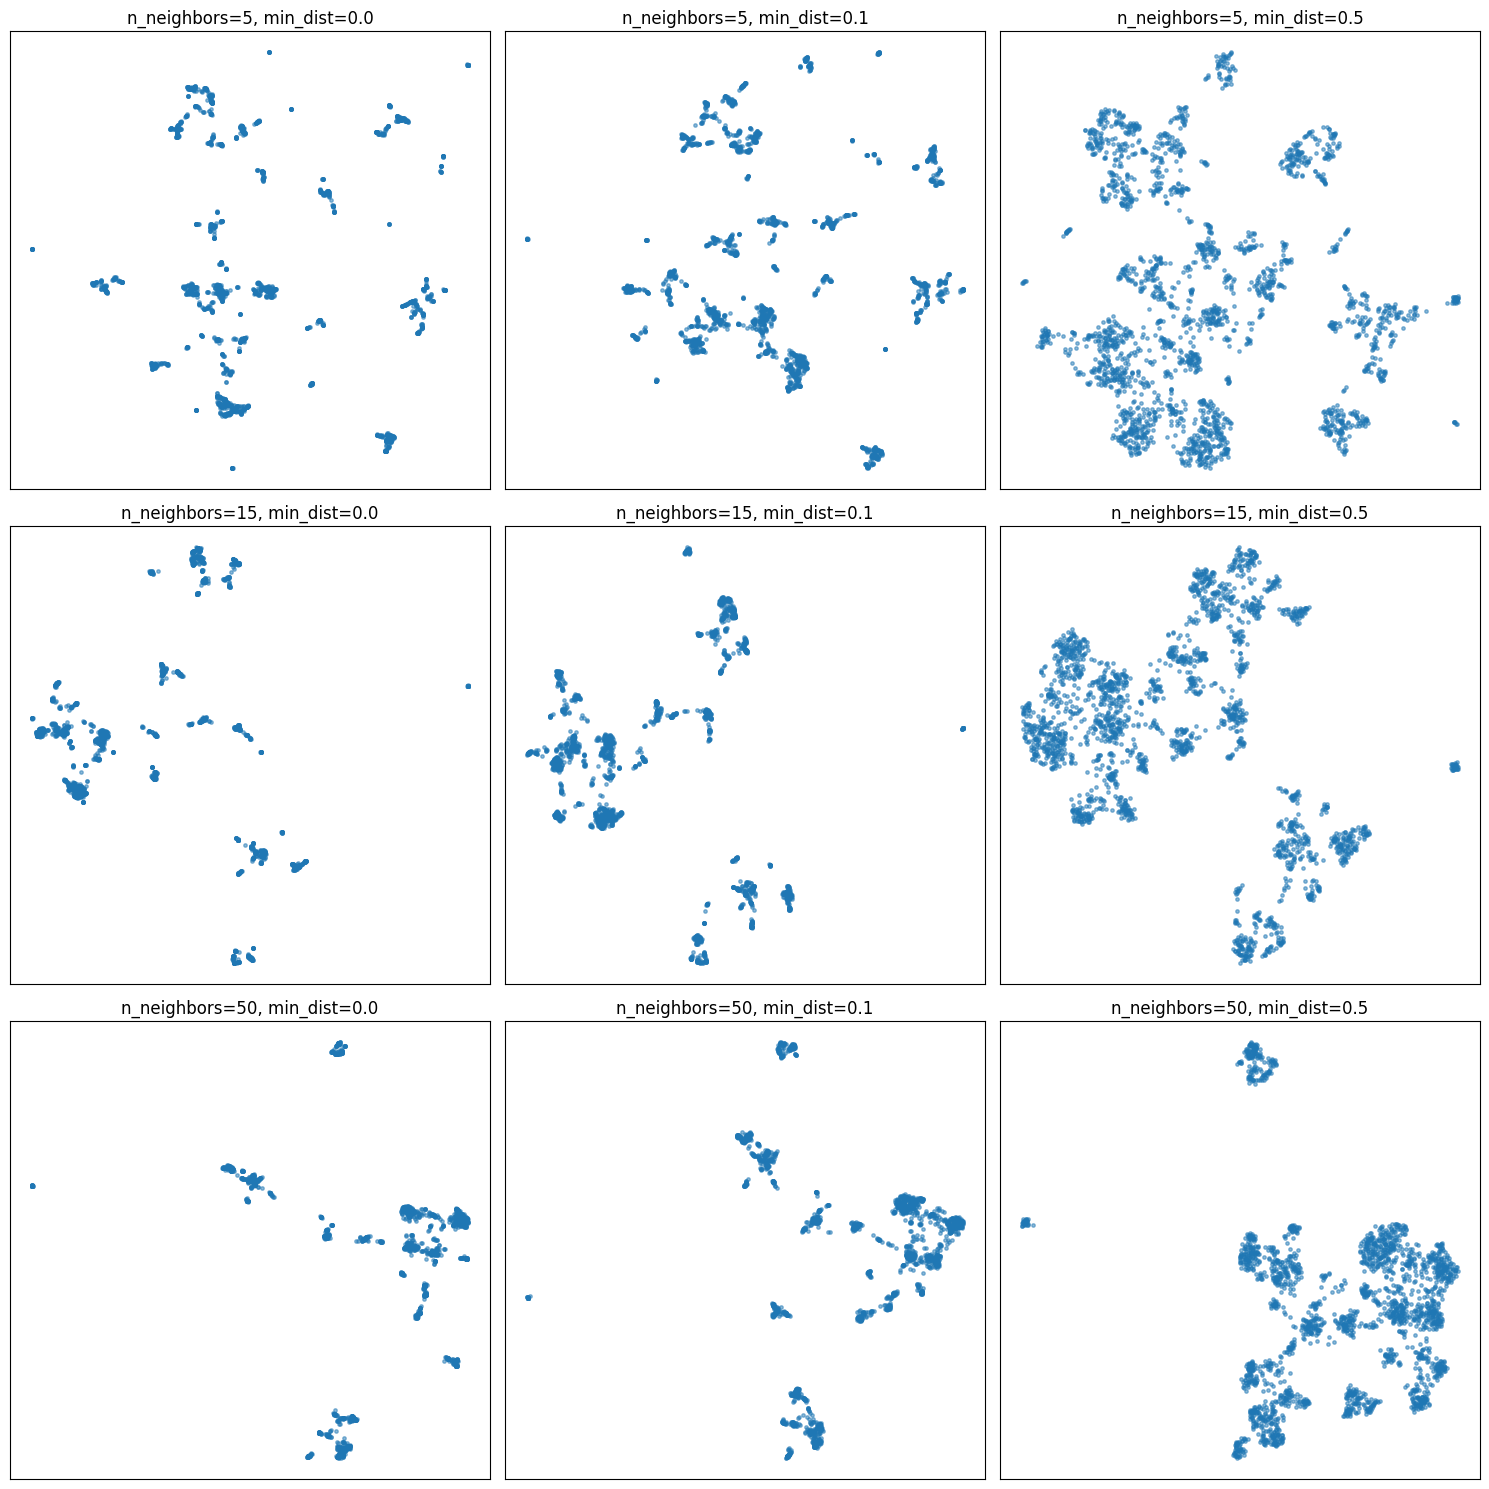

In [18]:
grid_n_neighbors = [5, 15, 50]
grid_min_dist = [0.0, 0.1, 0.5]

fig, axes = plt.subplots(3, 3, figsize=(15, 15))
for i, nn in enumerate(grid_n_neighbors):
    for j, md_ in enumerate(grid_min_dist):
        coords = eda_utils_emb_cluster.umap_project(
            emb, n_components=2,
            n_neighbors=nn, min_dist=md_,
            metric='cosine', random_state=0,
        )
        ax = axes[i][j]
        ax.scatter(coords[:, 0], coords[:, 1], alpha=0.5, s=6)
        ax.set_title(f'n_neighbors={nn}, min_dist={md_}')
        ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()


## 8. Final UMAP scatter colored by Agglomerative cluster labels

Edit `CHOSEN_N_NEIGHBORS` and `CHOSEN_MIN_DIST` below based on the grid
above, then re-run.


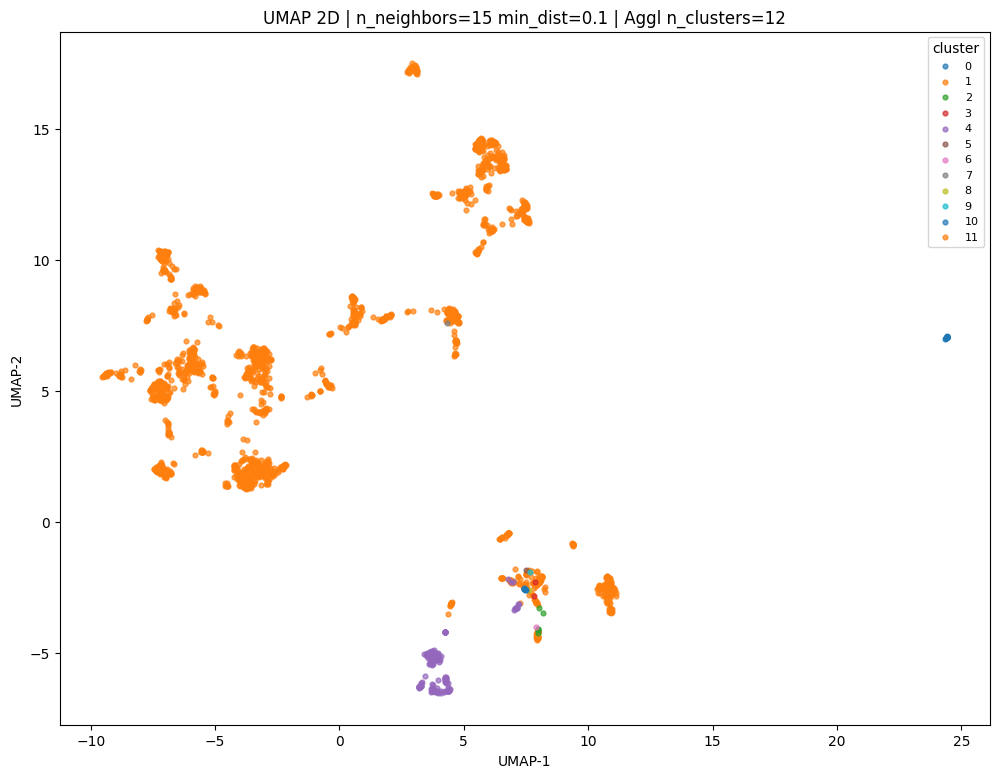

In [19]:
CHOSEN_N_NEIGHBORS = 15  # <-- replace after Section 7
CHOSEN_MIN_DIST    = 0.1  # <-- replace after Section 7
N_CLUSTERS         = 12

coords_2d = eda_utils_emb_cluster.umap_project(
    emb, n_components=2,
    n_neighbors=CHOSEN_N_NEIGHBORS, min_dist=CHOSEN_MIN_DIST,
    metric='cosine', random_state=0,
)
labels = eda_utils_emb_cluster.agglomerative_cluster(
    emb, n_clusters=N_CLUSTERS,
    linkage='average', metric='cosine',
)

fig, ax = plt.subplots(figsize=(12, 9))
eda_utils_emb_cluster.plot_umap_2d(
    coords_2d, labels=labels, ax=ax, alpha=0.7, s=12,
    title=(f'UMAP 2D | n_neighbors={CHOSEN_N_NEIGHBORS} '
           f'min_dist={CHOSEN_MIN_DIST} | Aggl n_clusters={N_CLUSTERS}'),
)
plt.show()


## 9. Notes AI SLOP

Companion writeup: `embeddings_notes.md` in this directory. Capture as you go:

* What stood out across KeyBERT, BERTopic, and the neighbors view?
* Where do BERTopic-HDBSCAN and BERTopic-Agglomerative disagree on the same corpus?
* Which UMAP hyperparameters held up visually?
* Which neighbor matches felt thematic vs. random?
* Where did AI assistance help vs. mislead during this work?
